# CIFAR-10 — Transfer Learning with ResNet-34

Fine-tuning a pre-trained ResNet-34 (ImageNet weights) on CIFAR-10.

**Strategy:**
- Resize CIFAR-10 images from 32×32 → 224×224 (ImageNet standard)
- Load `resnet34(weights='DEFAULT')` with pre-trained weights
- Replace the final FC layer for 10 classes
- Fine-tune with SGD + OneCycleLR (lower max_lr since weights are already good)
- Use `ModelCheckpoint` for crash protection & best model saving

## Imports

In [1]:
import sys
sys.path.append('..')

import torch
import torch.nn as nn
import torchvision.models as models
from torch import optim

from utils.dataset import get_cifar10_dataloaders, CLASSES
from utils.training import fit, test_accuracy
from utils.callbacks import ModelCheckpoint
from utils.plotting import plot_training_curves, show_sample_batch

## Device Setup

In [2]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
if device.type == 'cuda':
    torch.backends.cudnn.benchmark = True
print(f'Using device: {device}')

Using device: cuda


## Data Pipeline

Since the pre-trained ResNet-34 was trained on 224×224 ImageNet images,
we resize CIFAR-10 images to 224×224 to match the expected input resolution.
We use ImageNet normalization stats since the backbone was pre-trained with them.

In [3]:
batch_size = 64  # Smaller batch for 224×224 images

trainloader, valloader, testloader = get_cifar10_dataloaders(
    batch_size=batch_size,
    num_workers=4,
    img_size=224,
    use_imagenet_stats=True,
)

print(f'Train batches: {len(trainloader)} | Val batches: {len(valloader)} | Test batches: {len(testloader)}')

C:\Users\asmit\PycharmProjects\CIFAR_10\.venv\Lib\site-packages\torchvision\datasets\cifar.py:83: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  entry = pickle.load(f, encoding="latin1")


Train batches: 625 | Val batches: 157 | Test batches: 157


## Visualize Sample Batch

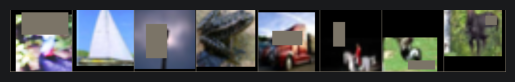

bird  ship  bird  frog  truck horse bird  deer 


In [4]:
show_sample_batch(trainloader, CLASSES, n=8)

## Model: Pre-trained ResNet-34

We load the ResNet-34 backbone with ImageNet weights,
then replace the final fully connected layer to output 10 classes.

The `BasicBlock` structure is identical to our custom ResNet-18,
but ResNet-34 is deeper (34 layers vs 18), giving it more capacity
to learn complex features — all while keeping the same lightweight block design.

In [5]:
model = models.resnet34(weights='DEFAULT')

# Replace the final FC layer (1000 classes → 10 for CIFAR-10)
num_features = model.fc.in_features  # 512
model.fc = nn.Linear(num_features, 10)

model.to(device)
print(f'Model parameters: {sum(p.numel() for p in model.parameters()):,}')

Model parameters: 21,289,802


## Training Configuration

Since the backbone is already pre-trained, we use a **lower max learning rate** (`0.01`)
compared to training from scratch (`0.1`). This prevents the fine-tuning from
destroying the pre-trained features.

In [6]:
criterion = nn.CrossEntropyLoss()
epochs = 45
optimizer = optim.SGD(model.parameters(), lr=0.001, momentum=0.9, weight_decay=5e-4)

scheduler = optim.lr_scheduler.OneCycleLR(
    optimizer,
    max_lr=0.01,
    steps_per_epoch=len(trainloader),
    epochs=epochs,
    pct_start=0.3,
    anneal_strategy='cos',
    div_factor=10,
    final_div_factor=1e3,
)

scaler = torch.amp.GradScaler('cuda')

checkpoint = ModelCheckpoint(
    model=model,
    checkpoint_path='../checkpoint/resnet34_transfer_latest.pth',
    best_model_path='../checkpoint/resnet34_transfer_best.pth',
    mode='max',
    verbose=True,
)

## Training Loop

In [7]:
train_losses, val_losses, val_accuracies = fit(
    model, trainloader, valloader, criterion,
    optimizer, scheduler, scaler, device, epochs, checkpoint,
)

[ModelCheckpoint] New best (max): 93.9100 — saved to ..\checkpoint\resnet34_transfer_best.pth
Epoch [ 1/45]  Train Loss: 0.7222  Val Loss: 0.1828  Val Acc: 93.91%  LR: 0.001121  Time: 37.05s
[ModelCheckpoint] New best (max): 94.2100 — saved to ..\checkpoint\resnet34_transfer_best.pth
Epoch [ 2/45]  Train Loss: 0.4175  Val Loss: 0.1764  Val Acc: 94.21%  LR: 0.001479  Time: 26.46s
Epoch [ 3/45]  Train Loss: 0.3670  Val Loss: 0.1770  Val Acc: 93.73%  LR: 0.002053  Time: 26.46s
[ModelCheckpoint] New best (max): 95.0200 — saved to ..\checkpoint\resnet34_transfer_best.pth
Epoch [ 4/45]  Train Loss: 0.3534  Val Loss: 0.1403  Val Acc: 95.02%  LR: 0.002813  Time: 26.55s
Epoch [ 5/45]  Train Loss: 0.3417  Val Loss: 0.1740  Val Acc: 94.26%  LR: 0.003718  Time: 26.42s
Epoch [ 6/45]  Train Loss: 0.3354  Val Loss: 0.1475  Val Acc: 94.85%  LR: 0.004719  Time: 26.55s
Epoch [ 7/45]  Train Loss: 0.3289  Val Loss: 0.3061  Val Acc: 90.73%  LR: 0.005763  Time: 26.37s
Epoch [ 8/45]  Train Loss: 0.3177  Val 

## Restore Best Weights & Test Evaluation

In [8]:
checkpoint.restore_best_weights()

overall_acc, per_class = test_accuracy(model, testloader, CLASSES, device)
print(f'\nOverall Test Accuracy: {overall_acc:.2f}%\n')
for name, acc in per_class.items():
    print(f'  {name:5s}: {acc:.1f}%')

[ModelCheckpoint] Restored best weights from ..\checkpoint\resnet34_transfer_best.pth (score=97.7300)

Overall Test Accuracy: 97.43%

  plane: 98.7%
  car  : 98.9%
  bird : 97.2%
  cat  : 93.4%
  deer : 97.4%
  dog  : 94.9%
  frog : 99.1%
  horse: 98.7%
  ship : 98.6%
  truck: 97.4%


## Training Curves

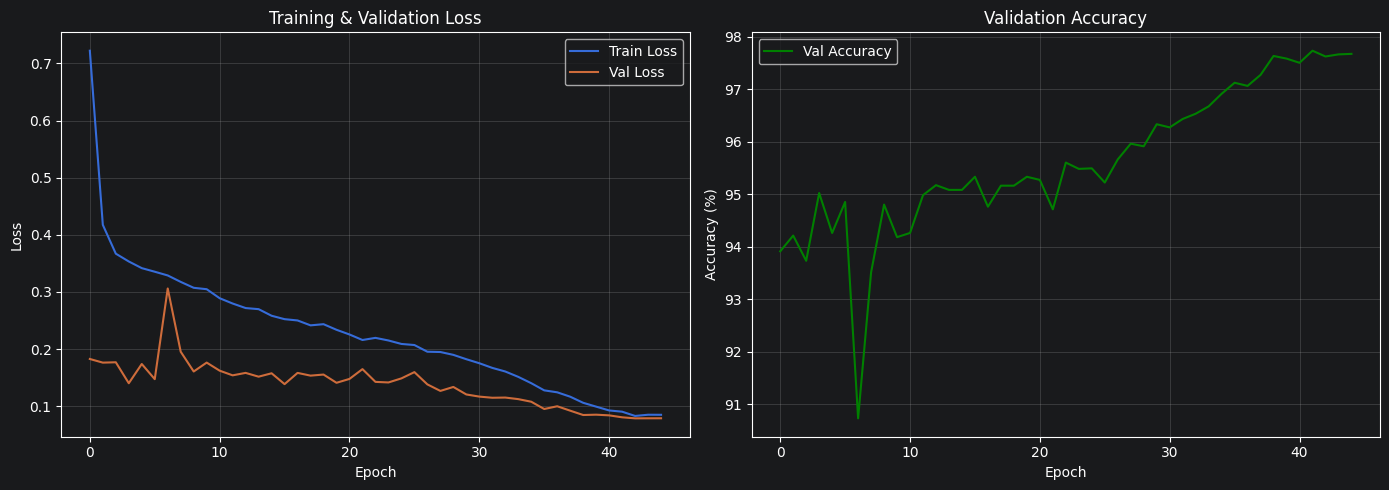

In [9]:
plot_training_curves(train_losses, val_losses, val_accuracies)